# Audio Features Extraction

In this notebook, we demonstrate methods for extracting audio features from music files. \
This process is primarily intended to generate visual representations that are used in the Theory chapter of the thesis.


In [126]:
# importing libraries
import os
import matplotlib.pyplot as plt
import librosa
import numpy as np
import librosa.display
import IPython.display as ipd
from matplotlib.pyplot import xticks

## Loading Audio Files

First we load the files and use IPython to listen to the sample. One can change the "GENRE_FOLDER" or the "SAMPLE_FILENAME", to view info of other files.\
We will use 2 files:
* A blues sample from the GTZAN dataset.
* A sample from a clean electric guitar playing the note A3. This will be useful to see the harmonics when applying DFT to view the frequency domain.

In [127]:
# Setting file location for blues sample
GENRE_FOLDER = "genres_full/blues"
SAMPLE_FILENAME = "blues.00000.wav"
blues_sample = os.path.join(GENRE_FOLDER, SAMPLE_FILENAME)

In [128]:
# Setting file location for guitar sample
GENRE_FOLDER = "sounds"
SAMPLE_FILENAME = "a_440_gtr.wav"
gtr_a3 = os.path.join(GENRE_FOLDER, SAMPLE_FILENAME)

In [129]:
# Listen to blues sample
ipd.Audio(blues_sample)

In [130]:
# Listen to the note
ipd.Audio(gtr_a3)

In [131]:
# Load files with librosa
blues_sample, sr_blues = librosa.load(blues_sample)
gtr_a3, sr_gtr_a3 = librosa.load(gtr_a3)


### Basic information regarding file

We present some basic information on the file

In [132]:
# Checking the shape of the files
blues_sample.shape, gtr_a3.shape

((661794,), (288092,))

In [133]:
# duration in seconds of 1 sample of the file
sample_duration = 1 / sr_blues
print(f"One sample lasts for {sample_duration:6f} seconds")

One sample lasts for 0.000045 seconds


In [134]:
# total number of samples in audio file
tot_samples = len(blues_sample)
tot_samples

661794

In [135]:
# duration of audio file sample in seconds
duration = 1 / sr_blues * tot_samples
print(f"The audio lasts for {duration} seconds")

The audio lasts for 30.013333333333335 seconds


## Visualizing audio signal in the time domain

We use the librosa library to view the waveform of the audio file

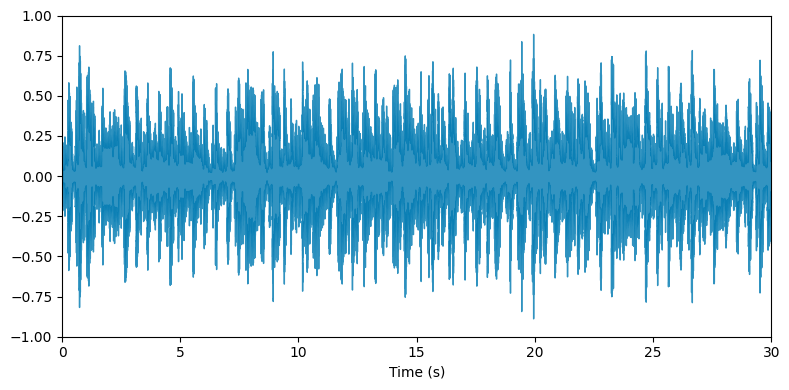

In [155]:
# Visualizing the whole waveform

# Create figure & axes explicitly
fig, ax = plt.subplots(figsize=(8, 4))

# White background
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Plot waveform in librosa
librosa.display.waveshow(
    blues_sample,
    ax=ax,
    color='#007AB2',
    alpha=0.8
)

# Axes labels
ax.set_xlabel("Time (s)", color='black')
# ax.set_ylabel("Amplitude", color='black')

# Axis limits and margins
ax.set_ylim(-1, 1)
ax.margins(x=0, y=0) # removing that will result having the default matplotlib presentation

# Tick colors
ax.tick_params(axis='x', colors='black')
ax.tick_params(axis='y', colors='black')

# Axis spines
for spine in ax.spines.values():
    spine.set_color('black')

plt.tight_layout()

# # save the plot
# plt.savefig(
#     "waveform.png",
#     dpi=144,
#     bbox_inches='tight',
#     facecolor=fig.get_facecolor()
# )

plt.show()


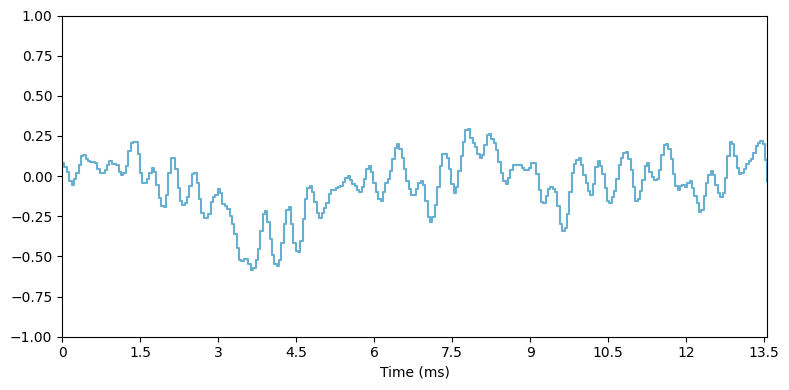

In [156]:
# Visualizing a segment of the audio file
audio_segment = blues_sample[5700:6000]

# Create figure & axes explicitly
fig, ax = plt.subplots(figsize=(8, 4))

# White background
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

librosa.display.waveshow(
    audio_segment,
    sr=sr_gtr_a3,
    ax=ax,
    color='#007AB2',
    axis="ms",
    alpha=0.6
)

# Axes labels
ax.set_xlabel("Time (ms)", color='black')
# ax.set_ylabel("Amplitude", color='black')

# Axis limits and margins
ax.set_ylim(-1, 1)
ax.margins(x=0, y=0) # removing that will result having the default matplotlib presentation

# Tick colors
ax.tick_params(axis='x', colors='black')
ax.tick_params(axis='y', colors='black')

# Axis spines
for spine in ax.spines.values():
    spine.set_color('black')

plt.tight_layout()

# # save the plot
# plt.savefig(
#     "waveform_segment.png",
#     dpi=144,
#     bbox_inches='tight',
#     facecolor=fig.get_facecolor()
# )

plt.show()


## Extracting the DFT - Visualizing the frequency domain

Here we will use the DFT to visualize the frequency domain, using the DFT.\
Keep in mind that applying the DFT on a signal will create artifacts after the Nyquist frequency. This is why we use the parameter `f_ratio`. Having an `f_ratio` of 1 will output the whole diagram. Having an `f_ratio` of 0.5 will output the 50% of the diagramm which is up to the Nyquist frequency./
On the note sample we will use an `f_ratio` of 0.1 because the harmonics appear up to the 10% of the plot. On the audio file, we will use an `f_ratio` of 0.5.

When using small `f_ratio` values, one can set the scale argument to `True` in order to have a more detailed x axis.

In [138]:
# Creating function to visualize the frequency domain
def plot_magnitude_spectrum(signal, sr, title=False, title_name="graph", filename="DFT.png", save=False, f_ratio=1, scale = False):
    # Compute FFT
    X = np.fft.fft(signal)
    X_mag = np.absolute(X)

    # Create figure & axes explicitly
    fig, ax = plt.subplots(figsize=(8, 4))

    # White background
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # Frequency axis
    f = np.linspace(0, sr, len(X_mag))
    f_bins = int(len(X_mag) * f_ratio)

    # Plot magnitude spectrum with same color and alpha
    ax.plot(f[:f_bins], X_mag[:f_bins], color='#007AB2', alpha=0.8)

    # Axes labels
    ax.set_xlabel("Frequency (Hz)", color='black')
    # ax.set_ylabel("Magnitude", color='black')

    ax.margins(x=0.01) # removing that will result having the default matplotlib presentation

    # Tick colors
    ax.tick_params(axis='x', colors='black')
    ax.tick_params(axis='y', colors='black')

    # Axis spines color
    for spine in ax.spines.values():
        spine.set_color('black')

    # Optionaly show more ticks (used with smaller samples)
    if scale:
        ax.set_xticks(np.arange(0, f[:f_bins][-1], 100))

    # Tight layout
    plt.tight_layout()

    # Put title
    if title and title_name:
        plt.title(title)

    # Save the plot
    if save and filename:
        plt.savefig(
            filename,
            dpi=144,
            bbox_inches='tight',
            facecolor=fig.get_facecolor()
        )

    # Show plot
    plt.show()

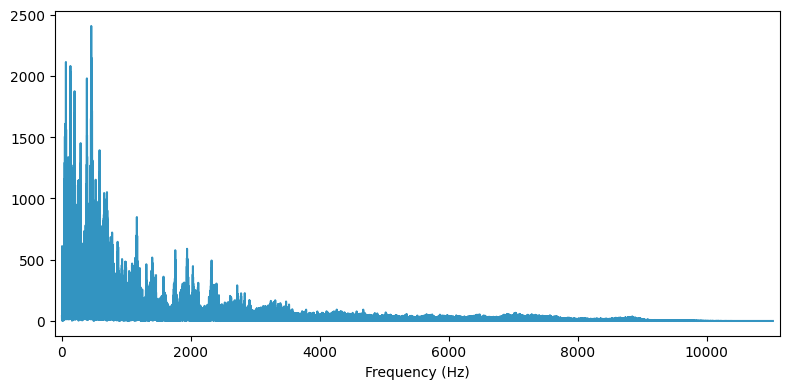

In [139]:
plot_magnitude_spectrum(blues_sample, sr_blues, filename="DFT_blues_sample.png", save=True, f_ratio=0.5)

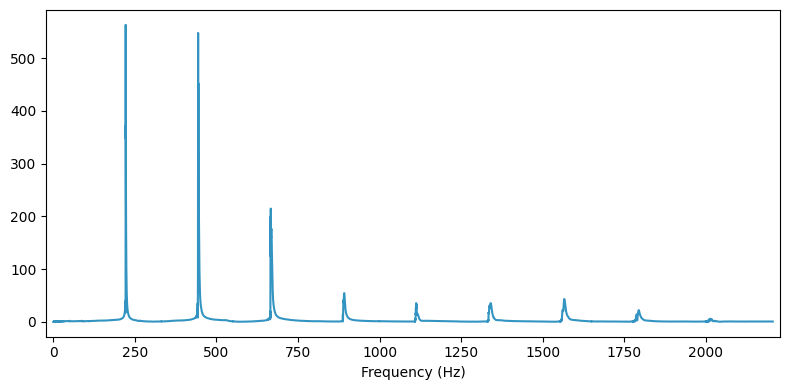

In [140]:
plot_magnitude_spectrum(gtr_a3, sr_gtr_a3, filename="DFT_gtr_a3.png", save=False, f_ratio=0.1, scale = False)

## Extracting Short-Time Fourier Transform

In order to perform the STFT, we have to set the `FRAME_SIZE`, as well as the `HOP_SIZE`. The stft is performed using the `librosa.stft()` method.

In [141]:
# Setting hyperparameters for the STFT
FRAME_SIZE = 2048
HOP_SIZE = 512

In [142]:
# Performing stft
S_blues = librosa.stft(blues_sample, n_fft=FRAME_SIZE, hop_length=HOP_SIZE)

### Calculating the spectrogram

The STFT yields for each point in time `t` and frequency `f` a complex number. The squared magnitude of this number is the spectrogram.\
So we use `np.abs()` to get the magnitude of the STFT output and then we square the result.

In [143]:
# Getting the squared magnitude
Y_blues = np.abs(S_blues) ** 2

### Visualizing the spectrogram

Creating a spectrogram with the magnitude in linear scale will most likely output an almost dark spectrogram, due to the fact that humans do not hear in linear scale

In [144]:
# Creating function to visualize spectrogram
def plot_spectrogram(Y, sr, hop_length, filename="spectrogram.png", save=False, y_axis="linear", cmap="viridis"):
    # Create figure & axes explicitly
    fig, ax = plt.subplots(figsize=(8, 4))

    # White background
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # Display spectrogram
    img = librosa.display.specshow(
                                    Y,
                                    sr=sr,
                                    hop_length=hop_length,
                                    x_axis="time",
                                    y_axis=y_axis,
                                    ax=ax,
                                    cmap=cmap
    )

    # Colorbar
    cbar = plt.colorbar(img, ax=ax, format="%+2.f")
    cbar.ax.yaxis.set_tick_params(color='black')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='black')

    # Axes labels color
    ax.set_xlabel("Time (s)", color='black')
    ax.set_ylabel("Frequency (Hz)", color='black')

    # Tick colors
    ax.tick_params(axis='x', colors='black')
    ax.tick_params(axis='y', colors='black')

    # Axis spines
    for spine in ax.spines.values():
        spine.set_color('black')

    # Tight layout
    plt.tight_layout()

    # Save the figure
    if save and filename:
        plt.savefig(
            filename,
            dpi=144,
            bbox_inches='tight',
            facecolor=fig.get_facecolor()
        )

    # Show the figure
    plt.show()


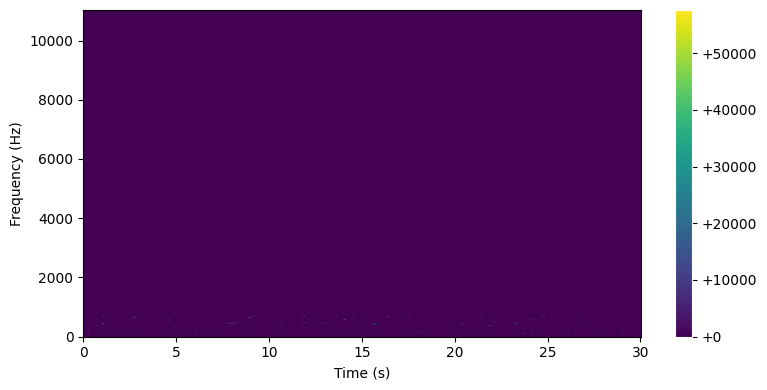

In [145]:
plot_spectrogram(Y_blues, sr_blues, HOP_SIZE)

### Log-Amplitude Spectrogram

We convert the amplitude to the dB scale which is logarithmic. As a result, the amplitude of the frequencies will be visible

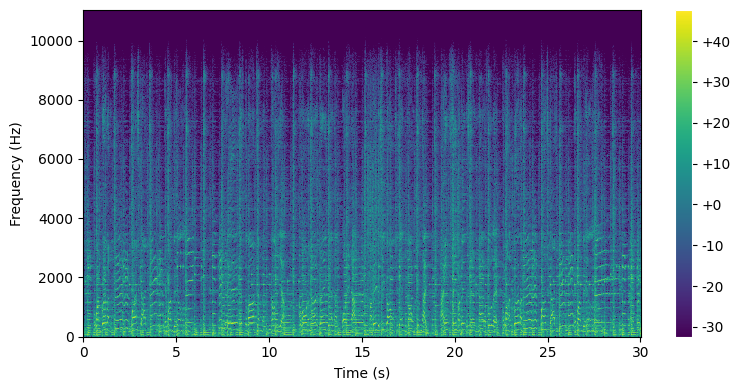

In [146]:
# changing the amplitude scale and plotting the corresponding spectrogram
Y_log_blues = librosa.power_to_db(Y_blues)
plot_spectrogram(Y_log_blues, sr_blues, HOP_SIZE, filename="spectrogram.png", save=False)

### Log-Frequency Spectrogram

Humans have a logarithmic perception of frequencies. To visualize that, we can turn the frequency axis to a logarithmic axis instead of linear. In that manner, we take the log-frequency spectrogram.

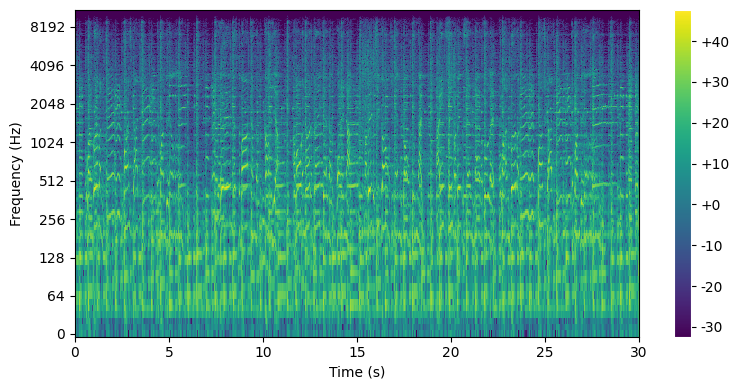

In [147]:
# Plotting the log-frequency spectrogram
plot_spectrogram(Y_log_blues, sr_blues, HOP_SIZE, filename="log-spectrogram.png", save=False, y_axis="log")

 ## Mel Spectrogram extraction

### Mel filterbanks

First we present a diagram that show how much each frequency bin contributes to a mel band. This visualization refers to the mel filter banks and can be done using librosa and particulary the `librosa.filters.mel()` method that outputs a linear transformation matrix to project FFT bins onto Mel-frequency bins. The `n_fft` argument refers to the size of time frames regarding how many samples they include. The `n_mels` argument sets the number of mel bands.

In [148]:
# Defining the mel banks transformation matrix
filter_banks = librosa.filters.mel(n_fft=2048, sr=sr_blues, n_mels=10)

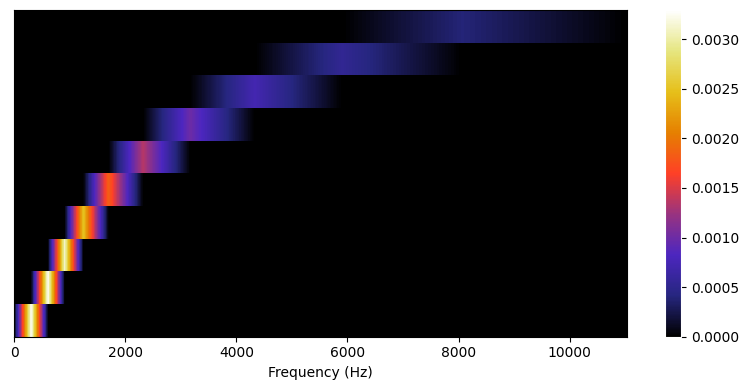

In [149]:
# Plotting the mel filter banks

# Create figure & axes explicitly
fig, ax = plt.subplots(figsize=(8, 4))

# White background
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Display the mel filter banks
img = librosa.display.specshow(
    filter_banks,
    sr=sr_blues,
    x_axis="linear",
    ax=ax,
    cmap="CMRmap"
)

# Colorbar with formatted ticks
cbar = plt.colorbar(img, ax=ax)
cbar.ax.yaxis.set_tick_params(color='black')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='black')

# Axes labels
ax.set_xlabel("Frequency (Hz)", color='black')
# ax.set_ylabel("Filter bank index", color='black')

# Tick colors
ax.tick_params(axis='x', colors='black')
ax.tick_params(axis='y', colors='black')

# Axis spines
for spine in ax.spines.values():
    spine.set_color('black')

# Tight layout
plt.tight_layout()

# # Save the figure
# plt.savefig(
#     "mel_filter_banks.png",
#     dpi=144,
#     bbox_inches='tight',
#     facecolor=fig.get_facecolor()
# )

# Show the figure
plt.show()


### Extracting the mel spectrogram

In [150]:
# Extracting the mel spectrogram tensor
mel_spectrogram = librosa.feature.melspectrogram(y=blues_sample, sr=sr_blues, n_fft=2048, hop_length=512, n_mels=64)

In [151]:
# Applying the dB scale to the magnitude of the spectrum
log_mel_spectrogram = librosa.power_to_db(mel_spectrogram)

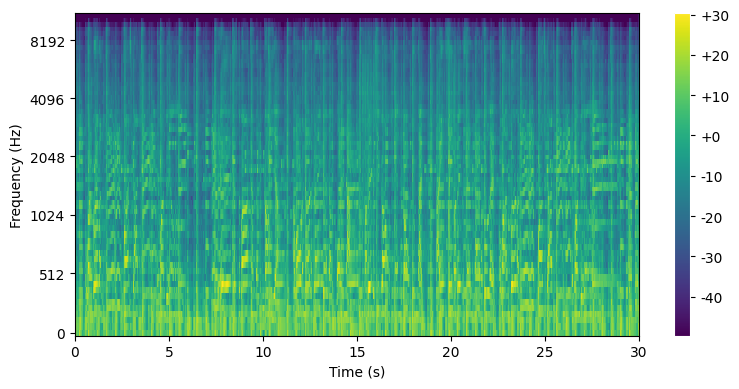

In [152]:
# Plotting the mel spectrogram

# Create figure & axes explicitly
fig, ax = plt.subplots(figsize=(8, 4))

# White background
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Display mel spectrogram
img = librosa.display.specshow(
                            log_mel_spectrogram,
                            sr=sr_blues,
                            x_axis="time",
                            y_axis="mel",
                            ax=ax,
                            cmap="viridis"
)

# Colorbar with formatted ticks
cbar = plt.colorbar(img, ax=ax, format="%+2.f")
cbar.ax.yaxis.set_tick_params(color='black')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='black')

# Axes labels
ax.set_xlabel("Time (s)", color='black')
ax.set_ylabel("Frequency (Hz)", color='black')

# Tick colors
ax.tick_params(axis='x', colors='black')
ax.tick_params(axis='y', colors='black')

# Axis spines
for spine in ax.spines.values():
    spine.set_color('black')

# Tight layout
plt.tight_layout()

# # Save the figure
# plt.savefig(
#     "mel_spectrogram.png",
#     dpi=144,
#     bbox_inches='tight',
#     facecolor=fig.get_facecolor()
# )

# Show the figure
plt.show()


## MFCC Extraction and visualization

We will use librosa for both the extraction and the visualization of MFCCs. We will use 13 MFCCs

In [153]:
# Extracting MFCCs
mfccs = librosa.feature.mfcc(y=blues_sample, n_mfcc=13, sr=sr_blues)

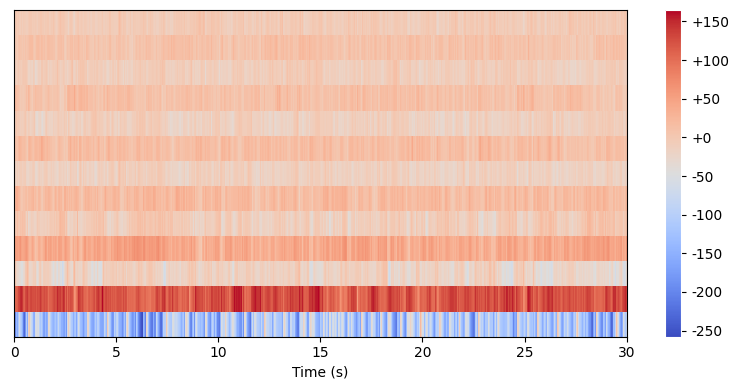

In [154]:
# Plotting the mel spectrogram with consistent style
fig, ax = plt.subplots(figsize=(8, 4))

# White background
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Display mel spectrogram
img = librosa.display.specshow(
                            mfccs,
                            sr=sr_blues,
                            x_axis="time",
                            ax=ax,
                            cmap="coolwarm"
)

# Colorbar with formatted ticks
cbar = plt.colorbar(img, ax=ax, format="%+2.f")
cbar.ax.yaxis.set_tick_params(color='black')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='black')

# Axes labels
ax.set_xlabel("Time (s)", color='black')

# Tick colors
ax.tick_params(axis='x', colors='black')
ax.tick_params(axis='y', colors='black')

# Axis spines
for spine in ax.spines.values():
    spine.set_color('black')

# Tight layout
plt.tight_layout()

# # Save the figure
# plt.savefig(
#     "MFCCs.png",
#     dpi=144,
#     bbox_inches='tight',
#     facecolor=fig.get_facecolor()
# )

# Show the figure
plt.show()
